In [885]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn import metrics
from sklearn.datasets  import load_iris

from six import StringIO
from IPython.display import Image
import pydotplus

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn import svm

import matplotlib as plt
import seaborn as sns; sns.set_theme(font_scale=1.2)

# Data Preparation

In [886]:
df = pd.read_csv("patient2025 - patient2025.csv")

In [887]:
df

,HN,FBS,BMI,Diabetes,Chorestorol,age,hypertension,"vegetarian (1= yes, 0=no)",Marriage Status,Exercise (min/week),Living Area,stroke
0,11223,228.69,34.0,yes,201-220,71.00,1,1,Yes,0.0,Bangkok,1
1,8887,202.21,NaN,No,180-200,52.00,1,0,Yes,90.0,Country,1
2,5666,105.92,30.5,yes,180-200,78.00,1,1,Yes,0.0,Country,1
3,460182,171.23,35.0,No,221-260,54.00,1,0,Yes,0.0,Bangkok,1
4,166665,174.12,28.0,No,180-200,79.00,1,0,Yes,90.0,Country,1
...,...,...,...,...,...,...,...,...,...,...,...,...
995,60211,90.51,18.9,yes,Unknown,1.40,0,0,No,120.0,Bangkok,0
996,53279,118.87,16.3,yes,Unknown,0.24,0,0,No,120.0,Country,0
997,61715,56.42,31.8,yes,180-200,55.00,0,0,Yes,0.0,Country,0
998,37830,73.67,21.0,No,Unknown,29.00,0,0,No,0.0,Bangkok,0


In [888]:
df['stroke'].value_counts()  

stroke
0    751
1    249
Name: count, dtype: int64

In [889]:
df.isnull().sum()

HN                            0
FBS                           0
BMI                          60
Diabetes                      0
Chorestorol                   0
age                           0
hypertension                  0
vegetarian (1= yes, 0=no)     0
Marriage Status               0
Exercise (min/week)          26
Living Area                   0
stroke                        0
dtype: int64

In [890]:
# convert data into number for DecisiontreeClassifier
df['Diabetes'] = df['Diabetes'].replace({'yes': 1, 'No': 0, 'No': 0})
df['hypertension'] = df['hypertension'].replace({'Yes': 1, 'No': 0})
df['Marriage Status'] = df['Marriage Status'].replace({'Yes': 1, 'No': 0})
df['Living Area'] = df['Living Area'].replace({'Bangkok': 1, 'Country': 0})
df['Chorestorol'] = df['Chorestorol'].replace('Unknown', np.nan)

C:\Users\PREDATOR\AppData\Local\Temp\ipykernel_40876\4292279877.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Diabetes'] = df['Diabetes'].replace({'yes': 1, 'No': 0, 'No': 0})
C:\Users\PREDATOR\AppData\Local\Temp\ipykernel_40876\4292279877.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Marriage Status'] = df['Marriage Status'].replace({'Yes': 1, 'No': 0})
C:\Users\PREDATOR\AppData\Local\Temp\ipykernel_40876\4292279877.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a f

In [891]:
df = df.dropna()

In [892]:
def chorestoral_mean(value):
    if isinstance(value, str):
        if '-' in value:
            try:
                lower, upper = map(float, value.split('-'))
                return (lower + upper) / 2
            except ValueError:
                return np.nan
    return value

In [893]:
df['Chorestorol'] = df['Chorestorol'].apply(chorestoral_mean)

C:\Users\PREDATOR\AppData\Local\Temp\ipykernel_40876\3676390341.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Chorestorol'] = df['Chorestorol'].apply(chorestoral_mean)


In [894]:
df

,HN,FBS,BMI,Diabetes,Chorestorol,age,hypertension,"vegetarian (1= yes, 0=no)",Marriage Status,Exercise (min/week),Living Area,stroke
0,11223,228.69,34.0,1,210.5,71.0,1,1,1,0.0,1,1
2,5666,105.92,30.5,1,190.0,78.0,1,1,1,0.0,0,1
3,460182,171.23,35.0,0,240.5,54.0,1,0,1,0.0,1,1
4,166665,174.12,28.0,0,190.0,79.0,1,0,1,90.0,0,1
5,56744,186.21,30.0,1,210.5,80.0,1,0,1,0.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
987,28122,77.44,21.4,0,210.5,37.0,0,0,1,90.0,0,0
990,66922,148.24,32.2,1,210.5,61.0,1,1,0,0.0,0,0
992,42786,72.93,27.1,1,210.5,82.0,0,1,1,90.0,0,0
994,24174,124.45,24.6,0,190.0,50.0,0,0,1,60.0,0,0


# Feature Selection

In [895]:
df_clean = df.drop(columns=['HN']).dropna()
feature_cols = ['FBS' , 'BMI','Diabetes','Chorestorol','age','hypertension' ,'vegetarian (1= yes, 0=no)','Marriage Status','Exercise (min/week)','Living Area' ]
x = df[feature_cols]
y = df['stroke']


In [896]:
# feature_cols = ['HN','FBS' , 'BMI','Diabetes','Chorestorol','age','hypertension' ,'vegetarian (1= yes, 0=no)','Marriage Status','Exercise (min/week)','Living Area' ]
# x = df[feature_cols]
# y = df['stroke']


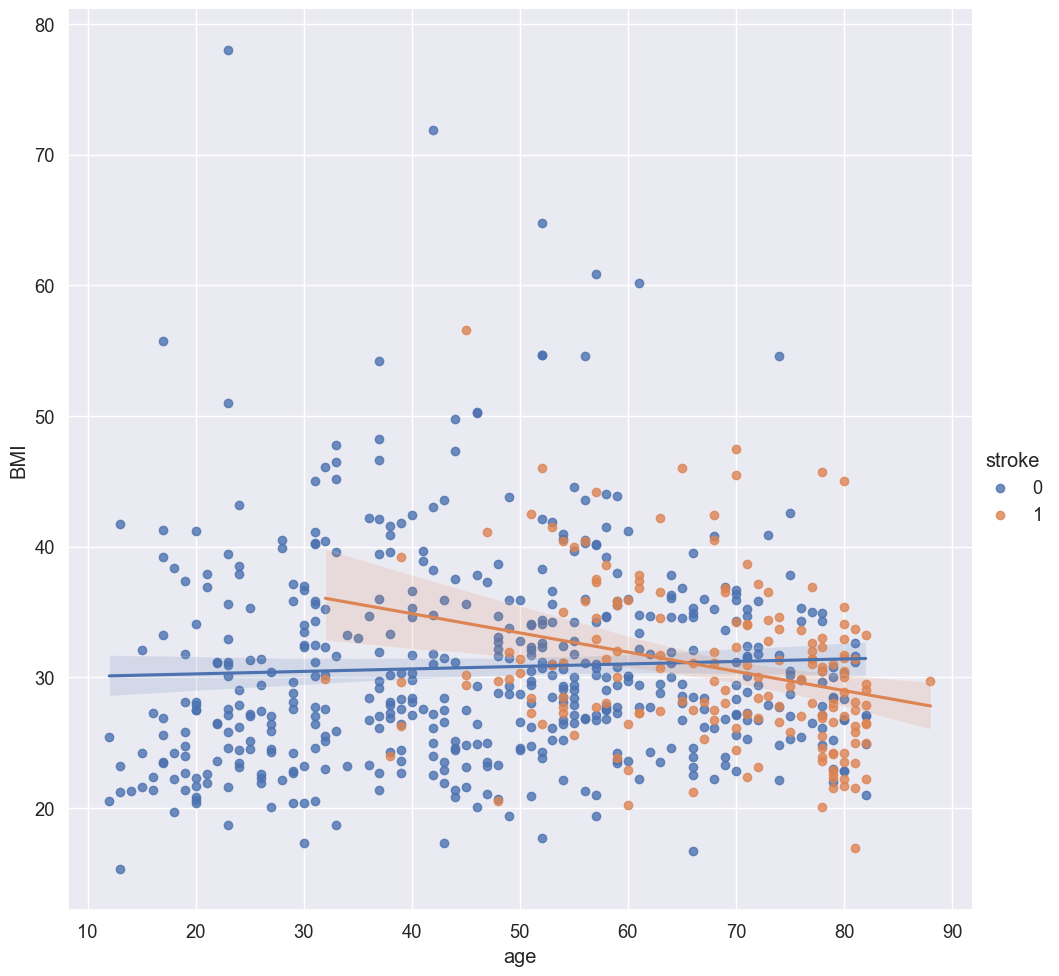

In [897]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lmplot(data=df, x="age", y="BMI", hue="stroke", height=10)

In [898]:
x_train , x_test , y_train , y_test = train_test_split(x , y, test_size= 0.3 , random_state=67 )

# Model Training

In [899]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto'],
}

grid = GridSearchCV(svm.SVC(), param_grid, verbose=2, cv=5, n_jobs=-1)
grid.fit(x_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print("Score:", grid.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Score: 0.7970212765957447


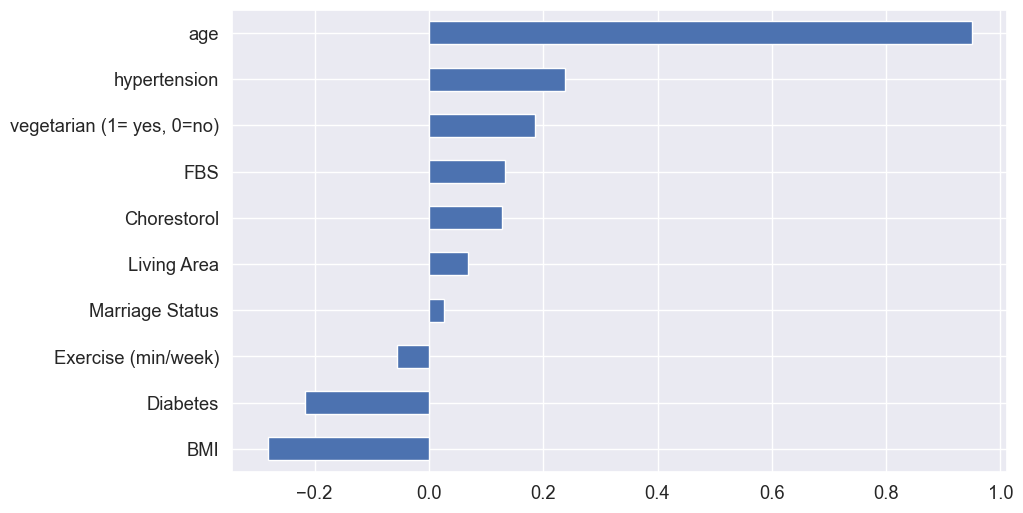

In [900]:
importances = pd.Series(grid.best_estimator_.coef_[0], index=feature_cols)

plt.figure(figsize=(10, 6))
importances.sort_values().plot(kind='barh')
plt.show()

<Figure size 800x600 with 0 Axes>

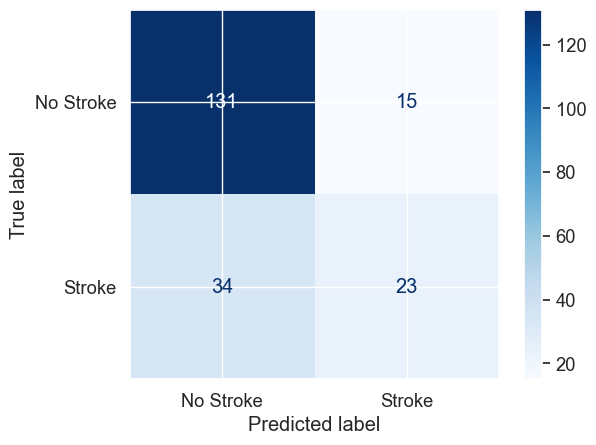

In [901]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred = grid.predict(x_test_scaled)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Stroke', 'Stroke'])

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d')
plt.show()

In [902]:
from sklearn.metrics import classification_report

y_pred = grid.predict(x_test_scaled)

print(classification_report(y_test, y_pred, target_names=['No Stroke', 'Stroke']))

              precision    recall  f1-score   support

   No Stroke       0.79      0.90      0.84       146
      Stroke       0.61      0.40      0.48        57

    accuracy                           0.76       203
   macro avg       0.70      0.65      0.66       203
weighted avg       0.74      0.76      0.74       203



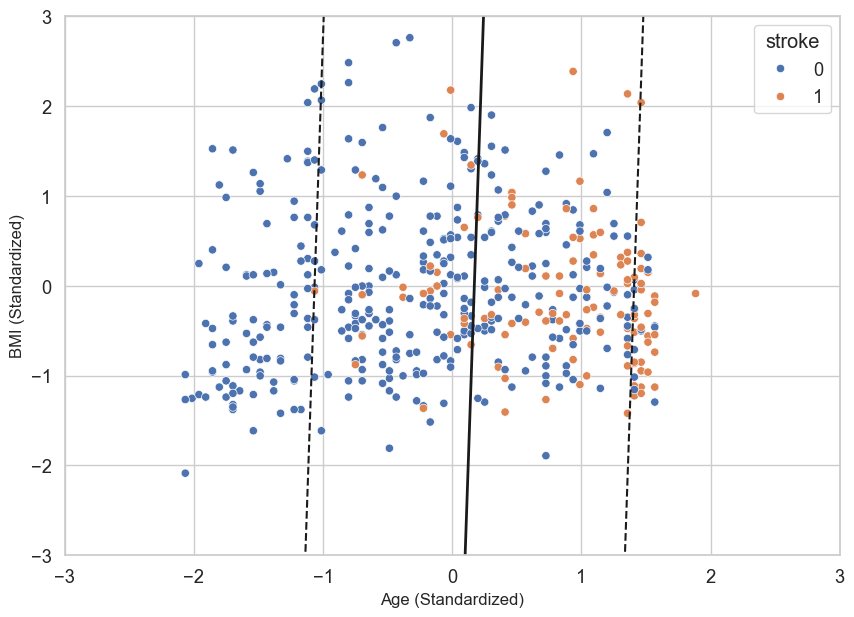

In [903]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import svm

X_viz = x_train_scaled[:, [4, 1]] 
y_viz = y_train

mask = (X_viz[:, 0] < 3) & (X_viz[:, 0] > -3) & (X_viz[:, 1] < 3) & (X_viz[:, 1] > -3)
X_plot, y_plot = X_viz[mask], y_viz[mask]

viz_model = svm.SVC(kernel='linear', C=0.01, class_weight='balanced')
viz_model.fit(X_plot, y_plot)

w = viz_model.coef_[0]
a = -w[0] / w[1]
xx = np.linspace(-3, 3) 
yy = a * xx - (viz_model.intercept_[0]) / w[1]

margin = 1 / np.sqrt(np.sum(viz_model.coef_ ** 2))
yy_down = yy - np.sqrt(1 + a**2) * margin
yy_up = yy + np.sqrt(1 + a**2) * margin

plt.figure(figsize=(10, 7), facecolor='white')
sns.set_style("whitegrid")

sns.scatterplot(x=X_plot[:, 0], y=X_plot[:, 1], hue=y_plot,)

plt.plot(xx, yy, 'k-', linewidth=2)
plt.plot(xx, yy_down, 'k--')
plt.plot(xx, yy_up, 'k--')

plt.scatter(viz_model.support_vectors_[:, 0], viz_model.support_vectors_[:, 1], 
            s=120, facecolors='none', linewidths=1.2,)

plt.xlim(-3, 3)
plt.ylim(-3, 3)

plt.xlabel("Age (Standardized)", fontsize=12)
plt.ylabel("BMI (Standardized)", fontsize=12)
plt.show()

In [904]:
def predict_stroke(patient_data):

    patient_array = np.array(patient_data).reshape(1, -1)
    
    scaled_patient = scaler.transform(patient_array)

    prediction = grid.predict(scaled_patient)
    
    return "Stroke" if prediction[0] == 1 else "No Stroke"

new_case = [120.5, 30.2, 1, 180.0, 70, 1, 0, 1, 30, 1]
print(f"Prediction for new case: {predict_stroke(new_case)}")

Prediction for new case: No Stroke


C:\Users\PREDATOR\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


C:\Users\PREDATOR\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


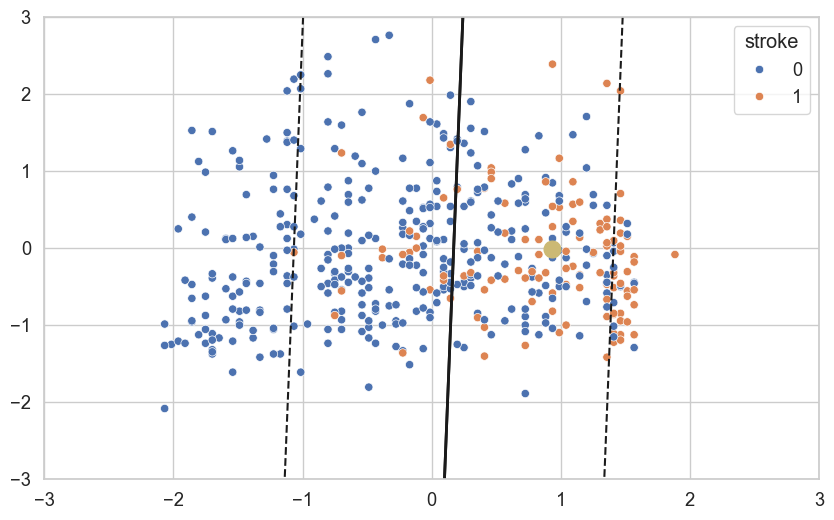

In [905]:

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_plot[:, 0], y=X_plot[:, 1], hue=y_plot)
plt.plot(xx, yy, 'k-', linewidth=2)
plt.plot(xx, yy, 'k-', linewidth=2)
plt.plot(xx, yy_down, 'k--')
plt.plot(xx, yy_up, 'k--')

new_case_scaled = scaler.transform(np.array(new_case).reshape(1, -1))
plt.plot(new_case_scaled[0, 4], new_case_scaled[0, 1], 'yo', markersize=12)

plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.show()